In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import db_mgmt as mgmt

In [9]:
file = 'outputs/canoe_ON/ON_16days.sqlite'
data = mgmt.sqlite_to_dfs(file)

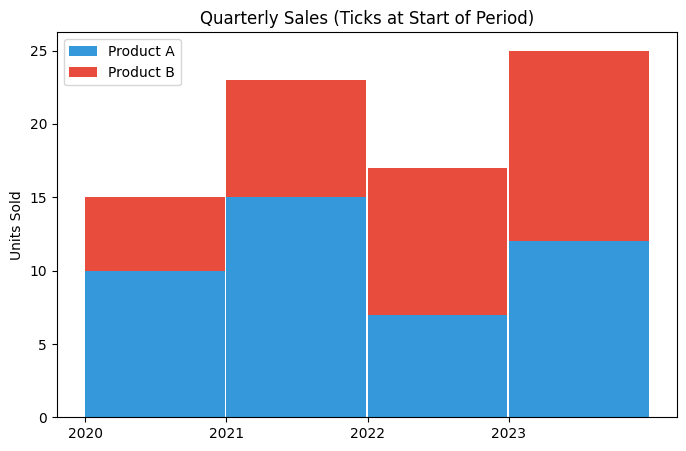

In [19]:
import matplotlib.pyplot as plt

periods = [int(2020), 2021, 2022, 2023]
sales_product_a = [10, 15, 7, 12]
sales_product_b = [5, 8, 10, 13]

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.99
# Plot the first layer
# align='edge' puts the tick at the start of the bar
ax.bar(periods, sales_product_a, label='Product A', 
       width=bar_width, align='edge', color='#3498db')

# Plot the second layer
# We use 'bottom' to stack it on top of Product A
ax.bar(periods, sales_product_b, label='Product B', 
       bottom=sales_product_a, width=bar_width, align='edge', color='#e74c3c')

# Formatting
ax.set_xticks(periods)
ax.set_title("Quarterly Sales (Ticks at Start of Period)")
ax.set_ylabel("Units Sold")
ax.legend()
plt.show()



In [39]:
df = pd.DataFrame({
    'period': [2020, 2020, 2021, 2021, 2022, 2022, 2023, 2023],
    'capacity': [10, 15, 7, 12, 10, 15, 7, 12],
    'tech': ['a', 'b', 'a', 'b','a', 'b', 'a', 'b']
})

df

,period,capacity,tech
0,2020,10,a
1,2020,15,b
2,2021,7,a
3,2021,12,b
4,2022,10,a
5,2022,15,b
6,2023,7,a
7,2023,12,b


T_LDV_C_DSL_N
T_LDV_C_BEV200_N
T_LDV_C_GSL_HEV_N
T_LDV_C_GSL_PHEV50_N
T_LDV_C_BEV150_N
T_LDV_C_FCEV400_N
T_LDV_C_BEV400_N
T_LDV_C_BEV300_N
T_LDV_C_GSL_PHEV35_N
T_LDV_C_GSL_N
T_LDV_C_CNG_N


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Stacked Performance (Ticks at Start)'}>)

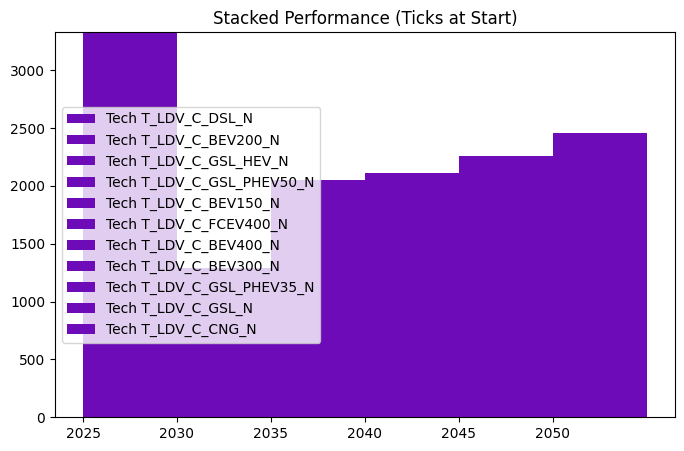

In [67]:
def plot_stacked_bar(df, x_col, y_col, hue_col, ax=None, color_scheme=None):
    # 1. If no ax is provided, create a new fig/ax
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.get_figure()

    # 2. Get unique categories and layers
    x_axis = df[x_col].unique()
    layers = df[hue_col].unique()
    if color_scheme is None:
        color_scheme = sns.color_palette("Set2", n_colors=len(layers))

    # 3. Use a pivot to ensure data alignment (handles missing values automatically)
    # This prevents the "bottom" calculation from breaking if rows are out of order
    plot_df = df.pivot(index=x_col, columns=hue_col, values=y_col).fillna(0)
    
    # 4. Loop through layers and stack
    bar_width = 5
    running_bottom = None

    for i, layer in enumerate(layers):
        values = plot_df[layer]
        
        ax.bar(plot_df.index, values, 
               label=f'Tech {layer}', 
               width=bar_width, 
               align='edge', 
               bottom=running_bottom,
               color=color_scheme[layers[i]])
        
        # Update the stack height
        if running_bottom is None:
            running_bottom = values.values
        else:
            running_bottom += values.values

    # 5. Formatting
    ax.set_xticks(x_axis)
    ax.set_title("Stacked Performance (Ticks at Start)")
    ax.legend()
    
    return fig, ax

df = data['OutputBuiltCapacity'].copy()
df = df.loc[df['tech'].str.contains('T_LDV_c', case=False)].reset_index(drop=True)
color_scheme = {tech: "#6e0bb9" for tech in df['tech'].unique()}
for tech in color_scheme.keys():
    print(tech)

plot_stacked_bar(df, x_col='vintage', y_col='capacity', hue_col='tech', ax=None, color_scheme=color_scheme)

In [73]:
vehicle_type = pd.read_csv('vehicle_type.csv')

In [74]:
fuel_colors = {
    "Jet Fuel": "#6A2A5B",
    "Electricity": "#FFB81C",
    "Diesel": "#002F6C",
    "Hyb": "#002F6C",
    "Hydrogen": "#D40072",
    "Gasoline": "#00A3AD",
    "Natural Gas": "#8E9399",
    "Plug in Hyb": "#FFB81C",
    "Marine Fuel": "#001A3D"
}